<a href="https://colab.research.google.com/github/SanikaPatil1008/Deep_Learning/blob/main/Exp_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9491 - loss: 0.1755 - val_accuracy: 0.9767 - val_loss: 0.0769
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9808 - loss: 0.0629 - val_accuracy: 0.9838 - val_loss: 0.0581
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9872 - loss: 0.0423 - val_accuracy: 0.9837 - val_loss: 0.0538
True Label: 7
Predicted Label: 7


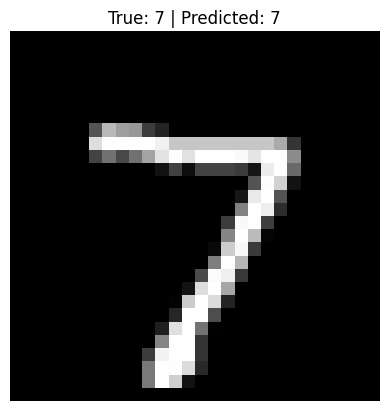

  0%|          | 0/1000 [00:00<?, ?it/s]

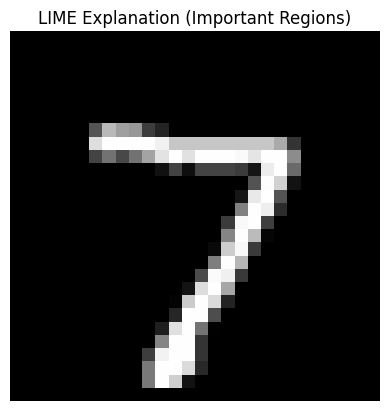

In [ ]:
# Install Libraries
!pip install -q lime tensorflow matplotlib

# Imports
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras import models, layers
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Load & Preprocess Data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Build Simple CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
model.fit(x_train, y_train, epochs=3, validation_split=0.1, verbose=1)

# Pick One Test Image
index = 0
image = x_test[index]
label = y_test[index]

# Model Prediction
pred = model.predict(image.reshape(1,28,28,1), verbose=0)
pred_label = np.argmax(pred)

print(f"True Label: {label}")
print(f"Predicted Label: {pred_label}")

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True: {label} | Predicted: {pred_label}")
plt.axis('off')
plt.show()

# LIME Explainer
explainer = lime_image.LimeImageExplainer()

# LIME needs 3-channel image
image_rgb = np.repeat(image, 3, axis=2)

# Prediction function
def predict_fn(images):
    images = np.array(images)
    images = images[..., 0:1]   # back to single channel
    return model.predict(images,verbose=0)

# Generate Explanation
explanation = explainer.explain_instance(
    image_rgb,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Get Explanation Image
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

# Show LIME Explanation
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation (Important Regions)")
plt.axis('off')
plt.show()